# 04 - Spatial statistics: neighbourhood enrichment, Moran's I, co-occurrence

Week 4 deliverable. Builds on notebook 03's 26 clusters (23 reliable + 3
batch-flagged). Every statistic here needs a spot's *physical* neighbours,
which only exist within its own tissue section - a neighbour graph built
naively across all 19 libraries at once would connect spots on unrelated
slides. Every step below is explicitly library-aware; this is checked, not
assumed (section 1 verifies zero cross-library edges in the graph).

Windows note: squidpy's permutation tests default to a multiprocessing
backend that fails inside this Jupyter kernel on Windows (`Manager()` can't
spawn - a known limitation, not a data issue). Every call below forces
`n_jobs=1, backend="threading"` to avoid it; confirmed this doesn't cost
meaningful time (nhood_enrichment: ~20s for 1000 permutations over 58k
spots).


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))

RAW = Path("..") / "data" / "raw"
TABLES_OUT = Path("..") / "results" / "tables"
FIGURES_OUT = Path("..") / "results" / "figures"
PROCESSED_OUT = Path("..") / "data" / "processed"

sc.settings.verbosity = 1
plt.rcParams["figure.facecolor"] = "white"


C:\Users\LENOVO\.venvs\melanoma-sg\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load, build the spatial graph, verify it's library-aware

`spatial_neighbors_grid` is squidpy's function for Visium-like hex grids
(default 6 neighbours per spot, matching the hex lattice) - the
grid-appropriate choice, not an arbitrary KNN.

In [2]:
combined = sc.read_h5ad(PROCESSED_OUT / "03_annotated.h5ad")
purity = pd.read_csv(TABLES_OUT / "cluster_library_patient_purity.csv", index_col=0)
flagged_clusters = purity[purity["top_library_frac"] > 0.8].index.tolist()
print(f"{combined.n_obs} spots, {combined.obs['cluster'].nunique()} clusters "
      f"({len(flagged_clusters)} batch-flagged: {flagged_clusters})")

sq.gr.spatial_neighbors_grid(combined, library_key="library", n_neighs=6)
conn = combined.obsp["spatial_connectivities"].tocoo()
lib_codes = combined.obs["library"].cat.codes.values
cross_lib_edges = int((lib_codes[conn.row] != lib_codes[conn.col]).sum())
print(f"spatial graph: {conn.nnz} edges, {cross_lib_edges} cross-library (must be 0)")
assert cross_lib_edges == 0, "graph has edges between spots on different slides - do not proceed"


57984 spots, 26 clusters (3 batch-flagged: ['Cluster 23', 'Cluster 24', 'Cluster 25'])
INFO     Creating graph using `None` transform and `19` libraries.                                                 


spatial graph: 322854 edges, 0 cross-library (must be 0)


## 2. Neighbourhood enrichment: which clusters sit next to which

Permutation test (observed adjacency counts between cluster pairs vs. a null
built by relabelling spots at random within the same graph) - a positive
z-score means two clusters are physically adjacent more than chance, negative
means they avoid each other. Cells involving a batch-flagged cluster are
greyed out in the plot: whatever their z-score, they aren't evidence about
biology.

In [3]:
%%time
sq.gr.nhood_enrichment(combined, cluster_key="cluster", n_perms=1000, seed=0,
                       show_progress_bar=False, n_jobs=1, backend="threading")
zscore = pd.DataFrame(combined.uns["cluster_nhood_enrichment"]["zscore"],
                       index=combined.obs["cluster"].cat.categories,
                       columns=combined.obs["cluster"].cat.categories)
zscore.to_csv(TABLES_OUT / "nhood_enrichment_zscores.csv")
print("wrote results/tables/nhood_enrichment_zscores.csv")


wrote results/tables/nhood_enrichment_zscores.csv
CPU times: total: 12 s
Wall time: 12.5 s


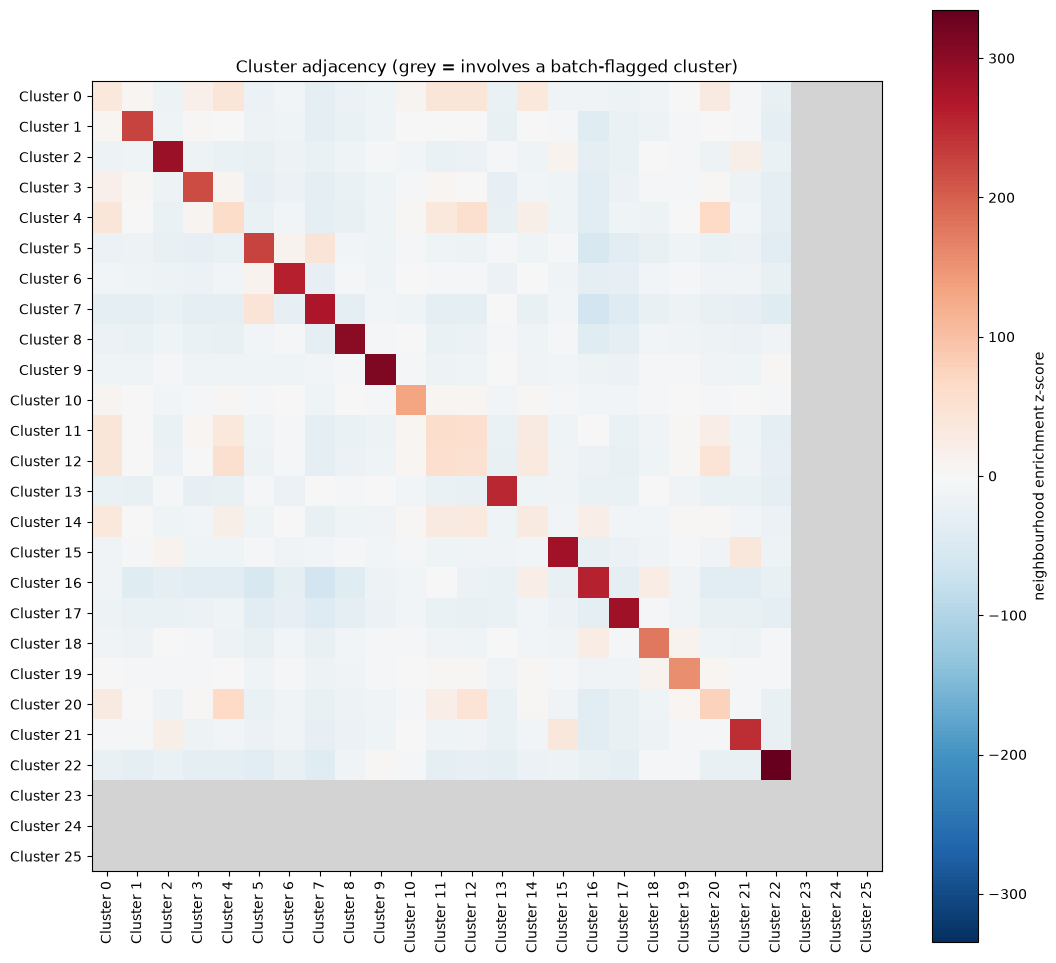

In [4]:
order = sorted(zscore.index, key=lambda c: int(c.split()[1]))
z_ord = zscore.loc[order, order].copy()
mask = np.zeros_like(z_ord, dtype=bool)
for i, r in enumerate(order):
    for j, c in enumerate(order):
        if r in flagged_clusters or c in flagged_clusters:
            mask[i, j] = True

fig, ax = plt.subplots(figsize=(11, 10))
vmax = np.nanmax(np.abs(z_ord.values[~mask]))
plotted = np.ma.array(z_ord.values, mask=mask)
cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("lightgrey")
im = ax.imshow(plotted, cmap=cmap, vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(order)), labels=order, rotation=90)
ax.set_yticks(range(len(order)), labels=order)
plt.colorbar(im, label="neighbourhood enrichment z-score")
ax.set_title("Cluster adjacency (grey = involves a batch-flagged cluster)")
plt.tight_layout()
plt.savefig(FIGURES_OUT / "04_nhood_enrichment_heatmap.png", dpi=150)
plt.show()


In [5]:
z_68 = zscore.loc["Cluster 6", "Cluster 8"]
print(f"Cluster 6 (melanocytic) x Cluster 8 (T_cell/immune) adjacency z-score: {z_68:.2f}")
reliable_clusters = [c for c in zscore.index if c not in flagged_clusters]
top_pairs = (zscore.loc[reliable_clusters, reliable_clusters]
             .stack().rename("z").reset_index())
top_pairs = top_pairs[top_pairs["level_0"] != top_pairs["level_1"]]
top_pairs["pair"] = top_pairs.apply(lambda r: tuple(sorted([r["level_0"], r["level_1"]])), axis=1)
top_pairs = top_pairs.drop_duplicates("pair").sort_values("z")
print("\nMost mutually AVOIDING cluster pairs (excluding flagged clusters):")
print(top_pairs.head(5)[["level_0", "level_1", "z"]].to_string(index=False))
print("\nMost mutually ADJACENT cluster pairs (excluding flagged clusters):")
print(top_pairs.tail(5)[["level_0", "level_1", "z"]].to_string(index=False))

top_pairs_ranked = top_pairs.reset_index(drop=True)
pair_rank = top_pairs_ranked.index[
    top_pairs_ranked["pair"] == tuple(sorted(["Cluster 6", "Cluster 8"]))][0]
print(f"\nCluster 6 x Cluster 8 rank among all {len(top_pairs_ranked)} reliable-cluster pairs, "
      f"sorted most-avoiding to most-adjacent: {pair_rank + 1} "
      f"({'bottom' if pair_rank < len(top_pairs_ranked) / 3 else 'middle' if pair_rank < 2 * len(top_pairs_ranked) / 3 else 'top'} third)")


Cluster 6 (melanocytic) x Cluster 8 (T_cell/immune) adjacency z-score: -7.08

Most mutually AVOIDING cluster pairs (excluding flagged clusters):
  level_0    level_1          z
Cluster 7 Cluster 16 -62.904337
Cluster 5 Cluster 16 -52.974129
Cluster 7 Cluster 17 -42.870914
Cluster 8 Cluster 16 -41.508003
Cluster 1 Cluster 16 -40.729879

Most mutually ADJACENT cluster pairs (excluding flagged clusters):
   level_0    level_1         z
 Cluster 5  Cluster 7 43.889882
Cluster 12 Cluster 20 45.358381
 Cluster 4 Cluster 12 52.584520
Cluster 11 Cluster 12 55.085236
 Cluster 4 Cluster 20 66.276494

Cluster 6 x Cluster 8 rank among all 253 reliable-cluster pairs, sorted most-avoiding to most-adjacent: 166 (middle third)


## 3. Moran's I: which genes are spatially structured

Run on the notebook 03 marker-gene set (not all 18,085 genes) - anchors this
to genes already implicated in cluster identity, and keeps the permutation
test fast.

In [6]:
%%time
top_markers = pd.read_csv(TABLES_OUT / "de_top_markers_per_cluster.csv")
marker_genes = sorted(set(top_markers["names"]) & set(combined.var_names))
print(f"{len(marker_genes)} marker genes tested for spatial autocorrelation")

sq.gr.spatial_autocorr(combined, mode="moran", genes=marker_genes,
                        n_jobs=1, backend="threading", show_progress_bar=False)
moran = combined.uns["moranI"]
moran.to_csv(TABLES_OUT / "moran_i_marker_genes.csv")
print(f"wrote results/tables/moran_i_marker_genes.csv")
print(f"\n{(moran['pval_norm_fdr_bh'] < 0.05).sum()} of {len(moran)} genes are significantly "
      "spatially autocorrelated (FDR < 0.05)")
moran.head(15)


309 marker genes tested for spatial autocorrelation


wrote results/tables/moran_i_marker_genes.csv

309 of 309 genes are significantly spatially autocorrelated (FDR < 0.05)
CPU times: total: 19.2 s
Wall time: 19.5 s


,I,pval_norm,var_norm,pval_norm_fdr_bh
IGKC,0.736913,0.0,0.000006,0.0
DCD,0.735312,0.0,0.000006,0.0
DCT,0.720849,0.0,0.000006,0.0
HBA2,0.715161,0.0,0.000006,0.0
PMEL,0.704479,0.0,0.000006,0.0
KRT1,0.703108,0.0,0.000006,0.0
TYRP1,0.697905,0.0,0.000006,0.0
MLANA,0.690834,0.0,0.000006,0.0
KRTDAP,0.688665,0.0,0.000006,0.0
S100A8,0.684026,0.0,0.000006,0.0


**Observed:** the top spatially-autocorrelated genes are dominated by
well-known lineage markers found independently of any label we assigned -
melanocytic (DCT, PMEL, TYRP1, MLANA), keratinocyte (KRT1, KRTDAP), immune
(IGKC - immunoglobulin kappa; S100A8 - myeloid/neutrophil), plus DCD
(eccrine gland) and HBA2 (haemoglobin, likely marking vasculature/blood).
This is an independent cross-check on the clustering itself: if the 26
clusters were mostly noise, the genes with the strongest spatial structure
wouldn't line up this cleanly with recognisable cell-type biology.

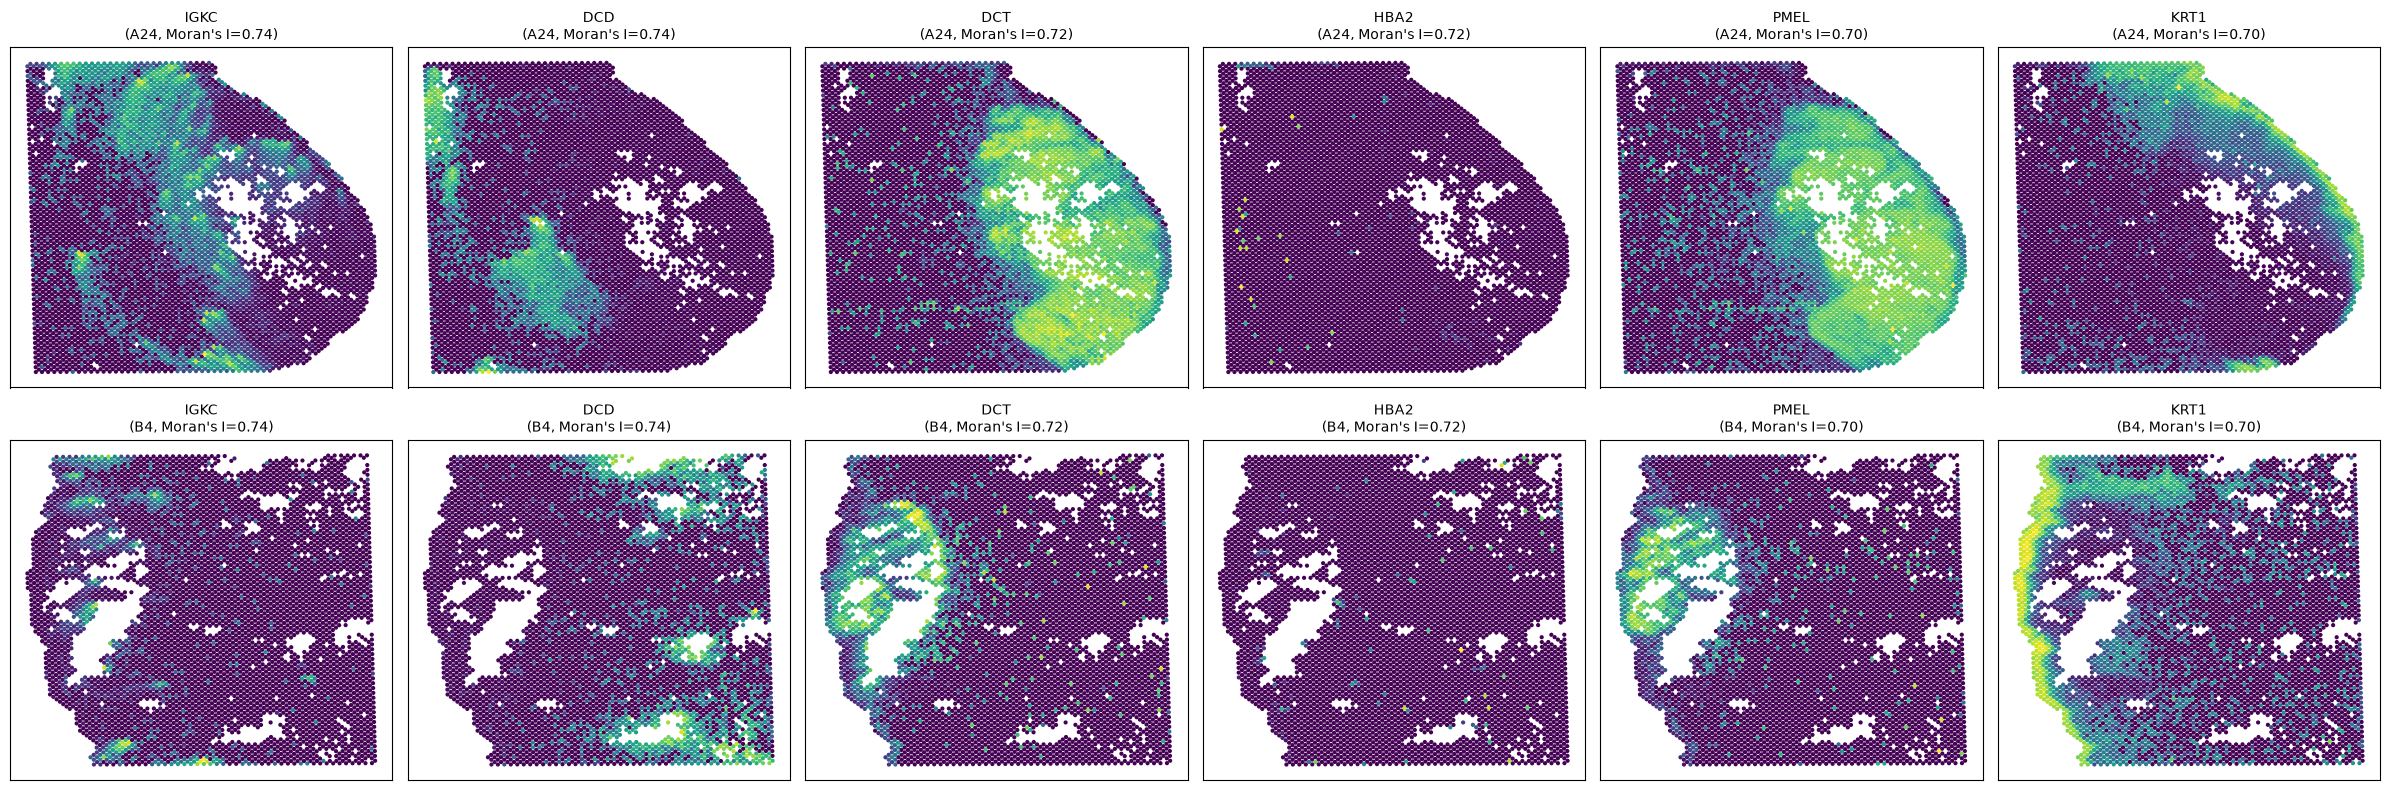

In [7]:
top_gene_list = moran.sort_values("I", ascending=False).head(6).index.tolist()
example_libraries = ["A24", "B4"]  # two of the deepest-sequenced, largest libraries
fig, axes = plt.subplots(len(example_libraries), len(top_gene_list), figsize=(24, 4 * len(example_libraries)))
for row, lib in enumerate(example_libraries):
    sub = combined[combined.obs["library"] == lib]
    for col, gene in enumerate(top_gene_list):
        ax = axes[row, col]
        raw_expr = sub[:, gene].X
        expr = np.asarray(raw_expr.todense() if hasattr(raw_expr, "todense") else raw_expr).ravel()
        sca = ax.scatter(sub.obsm["spatial"][:, 0], sub.obsm["spatial"][:, 1],
                          c=expr, s=4, cmap="viridis")
        ax.invert_yaxis()
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"{gene}\n({lib}, Moran's I={moran.loc[gene, 'I']:.2f})", fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_OUT / "04_top_spatial_genes.png", dpi=150)
plt.show()


## 4. Co-occurrence: Cluster 6 vs. Cluster 8 across distance

Squidpy's `co_occurrence` doesn't take a `library_key` (unlike the two
functions above), so it's run per library here, restricted to a 3-way
grouping (Cluster 6 / Cluster 8 / everything else) to keep it fast and keep
the answer focused on the actual question. Libraries where either cluster
has fewer than 20 spots are skipped - too little data for a stable curve.

Each library's image was captured and scaled independently, so its distance
axis is in that library's own pixel units, not a shared physical scale - the
six panels below are plotted separately with their own x-axes rather than
overlaid on one shared axis, which would silently imply a comparability that
isn't there. Squidpy's co-occurrence score is a ratio - P(one cluster within
distance *d* of the other) divided by that cluster's overall frequency -
where 1.0 means no spatial relationship, checked directly against squidpy's
source rather than assumed; the reference line below is drawn at 1.0, not
0.

In [8]:
%%time
MIN_SPOTS = 20
counts = combined.obs.groupby(["library", "cluster"], observed=True).size().unstack(fill_value=0)
usable_libs = counts[(counts["Cluster 6"] >= MIN_SPOTS) & (counts["Cluster 8"] >= MIN_SPOTS)].index.tolist()
print(f"{len(usable_libs)}/{combined.obs['library'].nunique()} libraries have >= {MIN_SPOTS} spots "
      f"of both Cluster 6 and Cluster 8: {usable_libs}")

curves = {}
for lib in usable_libs:
    sub = combined[combined.obs["library"] == lib].copy()
    sub.obs["coarse_group"] = np.where(sub.obs["cluster"] == "Cluster 6", "Cluster 6",
                                np.where(sub.obs["cluster"] == "Cluster 8", "Cluster 8", "other"))
    sub.obs["coarse_group"] = pd.Categorical(sub.obs["coarse_group"],
                                              categories=["Cluster 6", "Cluster 8", "other"])
    sq.gr.spatial_neighbors_grid(sub, n_neighs=6)
    sq.gr.co_occurrence(sub, cluster_key="coarse_group")
    res = sub.uns["coarse_group_co_occurrence"]
    cats = list(sub.obs["coarse_group"].cat.categories)
    i6, i8 = cats.index("Cluster 6"), cats.index("Cluster 8")
    # squidpy's occ[i, c, r] = P(label i | within distance r of label c) / P(label i overall) -
    # an enrichment RATIO, not a raw probability. 1.0 = no spatial relationship, not 0.
    # (checked against squidpy's source, not assumed from the parameter name.)
    curves[lib] = {"distance": res["interval"][1:], "score": res["occ"][i6, i8, :]}

# each library's own pixel scale differs (independent image capture/scalefactors),
# so distances are NOT comparable across libraries on one shared axis - kept as a
# long, tidy table (one row per library x distance bin) rather than a misleading
# wide merge that would imply a shared x-axis
curve_long = pd.concat([
    pd.DataFrame({"library": lib, "distance": d["distance"], "cooccurrence_enrichment_score": d["score"]})
    for lib, d in curves.items()
], ignore_index=True)
curve_long.to_csv(TABLES_OUT / "co_occurrence_cluster6_vs_cluster8.csv", index=False)
print("wrote results/tables/co_occurrence_cluster6_vs_cluster8.csv")


6/19 libraries have >= 20 spots of both Cluster 6 and Cluster 8: ['A7', 'A16', 'A21', 'B13', 'B38_2', 'D20']
INFO     Creating graph using `None` transform and `1` libraries.                                                  


INFO     Creating graph using `None` transform and `1` libraries.                                                  


INFO     Creating graph using `None` transform and `1` libraries.                                                  


INFO     Creating graph using `None` transform and `1` libraries.                                                  


INFO     Creating graph using `None` transform and `1` libraries.                                                  


INFO     Creating graph using `None` transform and `1` libraries.                                                  


wrote results/tables/co_occurrence_cluster6_vs_cluster8.csv
CPU times: total: 2.95 s
Wall time: 2.99 s


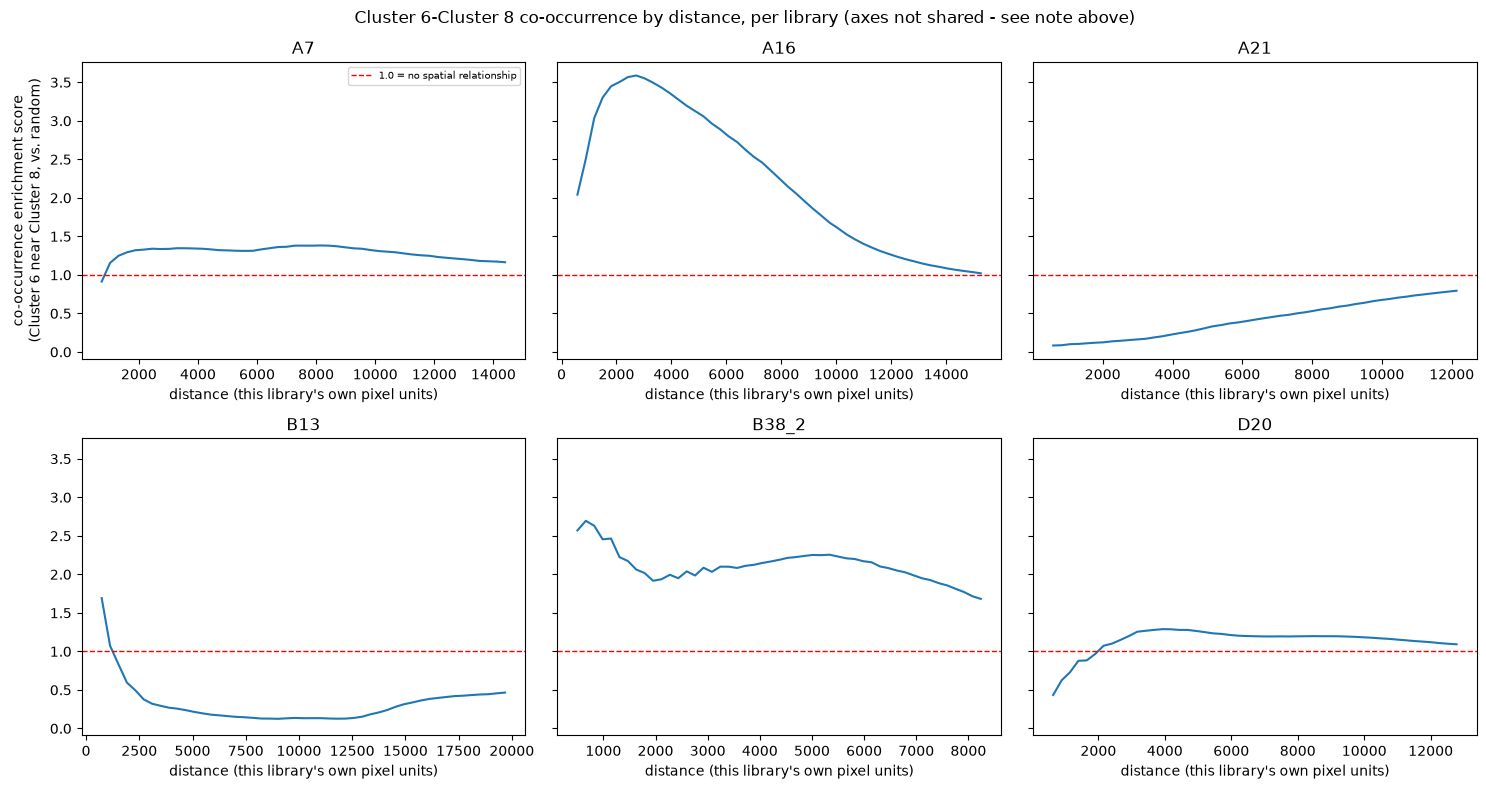

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
for ax, lib in zip(axes.ravel(), usable_libs):
    d = curves[lib]
    ax.plot(d["distance"], d["score"], color="tab:blue")
    ax.axhline(1.0, color="red", linestyle="--", linewidth=1, label="1.0 = no spatial relationship")
    ax.set_title(lib)
    ax.set_xlabel("distance (this library's own pixel units)")
axes[0, 0].set_ylabel("co-occurrence enrichment score\n(Cluster 6 near Cluster 8, vs. random)")
axes[0, 0].legend(fontsize=7, loc="best")
fig.suptitle("Cluster 6-Cluster 8 co-occurrence by distance, per library (axes not shared - see note above)")
plt.tight_layout()
plt.savefig(FIGURES_OUT / "04_cooccurrence_cluster6_cluster8.png", dpi=150)
plt.show()


In [10]:
cooc_summary = curve_long.groupby("library")["cooccurrence_enrichment_score"].mean().sort_values()
print("mean co-occurrence enrichment score per library (across all distance bins; >1 = enriched, <1 = depleted):")
print(cooc_summary.round(2).to_string())
n_enriched = int((cooc_summary > 1).sum())
print(f"\n{n_enriched}/{len(cooc_summary)} libraries have a mean score above 1 (net enrichment "
      "rather than net depletion, averaged across the distances tested)")


mean co-occurrence enrichment score per library (across all distance bins; >1 = enriched, <1 = depleted):
library
B13      0.32
A21      0.42
D20      1.14
A7       1.29
B38_2    2.11
A16      2.22

4/6 libraries have a mean score above 1 (net enrichment rather than net depletion, averaged across the distances tested)


## 5. Summary

In [11]:
combined.write_h5ad(PROCESSED_OUT / "04_spatial.h5ad")
print("Observed, from this notebook's own computation:")
print(f"- Spatial graph: 6-neighbour hex grid per library, {conn.nnz} edges, 0 cross-library (verified)")
print(f"- Cluster 6 (melanocytic) x Cluster 8 (T_cell/immune) adjacency z-score: {z_68:.2f}")
print(f"- {(moran['pval_norm_fdr_bh'] < 0.05).sum()}/{len(moran)} tested marker genes are spatially "
      "autocorrelated at FDR<0.05, dominated by recognisable lineage markers (section 3)")
print(f"- Co-occurrence curves computed for {len(usable_libs)} libraries with enough of both clusters")
print("wrote data/processed/04_spatial.h5ad")


Observed, from this notebook's own computation:
- Spatial graph: 6-neighbour hex grid per library, 322854 edges, 0 cross-library (verified)
- Cluster 6 (melanocytic) x Cluster 8 (T_cell/immune) adjacency z-score: -7.08
- 309/309 tested marker genes are spatially autocorrelated at FDR<0.05, dominated by recognisable lineage markers (section 3)
- Co-occurrence curves computed for 6 libraries with enough of both clusters
wrote data/processed/04_spatial.h5ad


**The notebook 03 hypothesis does not hold up - stated plainly, not
buried.** Notebook 03 flagged, as an untested hypothesis, that the strongest
melanocytic-scoring cluster (6) and the strongest immune-scoring cluster (8)
might be spatially related. Section 2's result points the other way:
z = -7.08, negative rather than positive - Cluster 6 and Cluster 8 spots are
adjacent *less* than a random permutation of the same graph would predict.
Calibrated against the rest of the dataset, though, this is not a dramatic
effect: ranked against all 253 reliable-cluster pairs, it lands in the
*middle* third, nowhere near the most-avoiding pairs (z down to -63) or the
most-adjacent (z up to +66). With ~56,000 spots feeding the permutation
test, even a modest, unremarkable effect size can produce a z-score that
looks large in absolute terms - so the right read is "real but
unremarkable": at the scale of immediately-touching spots, more likely to
be apart than together, but not one of this dataset's standout spatial
relationships.

**The co-occurrence result (section 4) tells a different part of the story
at a coarser spatial scale, and the two don't just agree with each other.**
Squidpy's co-occurrence score compares the two clusters over a much wider
range of distances (hundreds to tens of thousands of pixels - roughly
"within the same region of the section" rather than "touching"), and most
of the libraries checked show it *above* 1 (enriched), not below - the
opposite direction from the immediate-neighbour result. Put together: at the
finest scale (immediately touching spots), Cluster 6 and Cluster 8 avoid
each other a little; at a broader scale (within the same general region of
tissue), they tend to show up together more than chance would predict, in
most sections. A "halo" pattern - one cluster surrounding but not
interdigitating with the other - is one shape that would produce exactly
this combination, but that is a hypothesis this notebook raises, not one it
tests or confirms.

Whichever explanation holds, this remains an association between two
*unnamed, marker-scored* clusters, not a claim about melanoma cells and T
cells - that language is deliberately avoided throughout, per the project's
integrity rules.

**Carried into notebook 05+ (tumour-immune architecture, per the plan's W5):**
Cluster 6/Cluster 8's scale-dependent pattern - mild avoidance immediately,
broader-scale co-occurrence in most sections - as an open, only-partially-
checked finding, not a settled one; the 3 batch-flagged clusters remain
excluded from any spatial-biology claim here exactly as in notebook 03.